In [3]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
import soundfile as sf
from IPython.display import Markdown, Audio, display

import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
WINDOW_SIZE = 128
HOP_SIZE = WINDOW_SIZE #No overlap setting

NOISY_AUDIO_PATH = 'LibriSpeechNoisy\\'

## Pre-processing

In [5]:
def get_flac_file_paths(root_folder):
    flac_file_paths = []
    for dirpath, _, filenames in os.walk(root_folder):
        for file in filenames:
            if file.endswith('.flac'):
                full_path = os.path.join(dirpath, file)
                flac_file_paths.append(full_path)
    return flac_file_paths


def calc_audio_stft(audio_data):
    spectogram = np.abs(librosa.stft(audio_data, n_fft=WINDOW_SIZE, hop_length=HOP_SIZE))  # Magnitude of the STFT
    spectogram = librosa.amplitude_to_db(spectogram, ref=np.max)
    return spectogram


def plot_waveform(audio_data, sample_rate):
    sample_count = len(audio_data)
    recording_time = sample_count / sample_rate

    time_axis = np.linspace(0, recording_time, sample_count)

    # Plot the waveform
    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, audio_data, color="green")
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    #plt.xlim([start_time, end_time])
    plt.title('Amplitude Graph of the WAV File')
    plt.show()


def apply_noising_on_audio(file_path, audio_data, sample_rate, noise_factor = 0.01):
    noise = np.random.randn(len(audio_data))
    noisy_data = audio_data + noise_factor * noise  # Adjust noise factor

    file_name = os.path.basename(file_path).removesuffix(".flac")
    folders = file_path.replace('LibriSpeech/', '').rsplit('\\', 1)[0]
    new_file_name = file_name + "-noisy.flac"

    new_path = NOISY_AUDIO_PATH + folders
    
    if not os.path.exists(new_path):
        os.makedirs(new_path)
    
    sf.write(new_path + "\\" + new_file_name, noisy_data, sample_rate)

    return noisy_data, new_path + "\\" + new_file_name


def plot_spectogram(spectogram, sample_rate):
    # Plot the spectrogram
    plt.figure(figsize=(10, 6))
    librosa.display.specshow(spectogram, sr=sample_rate, x_axis='time', y_axis='log', n_fft=WINDOW_SIZE, hop_length=HOP_SIZE)
    plt.colorbar(format='%+2.0f dB')
    plt.yticks([64,100,1000,4096, 8000])
    #plt.ylim(0, sample_rate / 2)  # Ensures Y-axis goes up to 8000 Hz
    plt.title('Spectrogram')
    plt.show()


def play_audio(file_path, title, autoplay=False):
    title = f"## {title}"
    display(Markdown(title))
    #display(Audio(audio_file_path))
    return Audio(file_path, autoplay=autoplay)

In [12]:
data_paths = get_flac_file_paths("LibriSpeech/")

In [13]:
raw_data, sample_rate = librosa.load(data_paths[0], sr=None)

In [14]:
raw_data_noisy, noisy_data_path = apply_noising_on_audio(data_paths[0], raw_data, sample_rate)

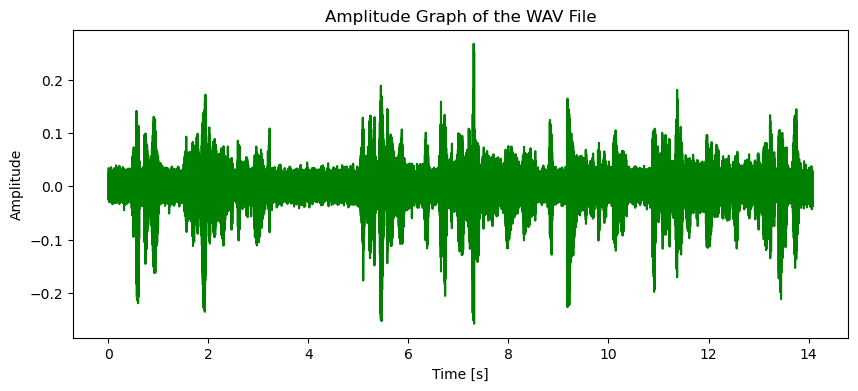

In [15]:
plot_waveform(raw_data_noisy, sample_rate)

In [16]:
audio_file_path = data_paths[0]
audio_file_path_noisy = noisy_data_path

In [17]:
play_audio(audio_file_path, "Clean recording")

## Clean recording

In [18]:
play_audio(audio_file_path_noisy, "Noisy recording")

## Noisy recording

## 1D Unet

In [19]:
# Applying segmentation on both clean and noisy data
frames_clean = librosa.util.frame(raw_data, frame_length=WINDOW_SIZE, hop_length=HOP_SIZE)
frames_noisy = librosa.util.frame(raw_data_noisy, frame_length=WINDOW_SIZE, hop_length=HOP_SIZE)

# Transpose to get shape (num_frames, window_size)
segments_clean = frames_clean.T
segments_noisy = frames_noisy.T

window_size = segments_clean.shape[1]

In [20]:
segments_clean.shape[0]

1760

In [21]:
def unet_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Downsampling
    c1 = layers.Conv1D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv1D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling1D((2))(c1)

    c2 = layers.Conv1D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv1D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling1D((2))(c2)

    c3 = layers.Conv1D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv1D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling1D((2))(c3)

    # Bottleneck
    c4 = layers.Conv1D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv1D(512, 3, activation='relu', padding='same')(c4)

    # Upsampling
    u5 = layers.Conv1DTranspose(256, 2, strides=2, padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv1D(256, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv1D(256, 3, activation='relu', padding='same')(c5)

    u6 = layers.Conv1DTranspose(128, 2, strides=2, padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv1D(128, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv1D(128, 3, activation='relu', padding='same')(c6)

    u7 = layers.Conv1DTranspose(64, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv1D(64, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv1D(64, 3, activation='relu', padding='same')(c7)

    outputs = layers.Conv1D(1, 1, activation='tanh')(c7)  # Change activation as needed

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

In [22]:
# Create the model
input_shape = (window_size, 1)  # 1 channel for 1D audio
model = unet_model(input_shape)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [24]:
# Reshape segments for training
segments_noisy = segments_noisy.reshape(-1, window_size, 1)
segments_clean = segments_clean.reshape(-1, window_size, 1)

# Train the model
history = model.fit(segments_noisy, segments_clean, batch_size=32, epochs=20, validation_split=0.2)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3.4814e-05 - mae: 0.0043 - val_loss: 4.1008e-05 - val_mae: 0.0048
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 3.3233e-05 - mae: 0.0042 - val_loss: 3.6744e-05 - val_mae: 0.0045
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 3.2244e-05 - mae: 0.0041 - val_loss: 3.7568e-05 - val_mae: 0.0046
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3.3040e-05 - mae: 0.0042 - val_loss: 3.8510e-05 - val_mae: 0.0047
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 3.0169e-05 - mae: 0.0040 - val_loss: 3.6189e-05 - val_mae: 0.0045
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3.1787e-05 - mae: 0.0041 - val_loss: 4.0241e-05 - val_mae: 0.0048
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 3.2426e-05 - mae: 0.0042 - val_loss: 3.5255e-05 - val_mae: 0.0044
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 2.9870e-05 - mae: 0.0040 - val_loss: 3.5599e-05 - val_mae: 0.0044


KeyboardInterrupt: 

In [110]:
# Denoise new audio
denoised_audio = model.predict(segments_noisy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


In [111]:
denoised_audio = denoised_audio.flatten()

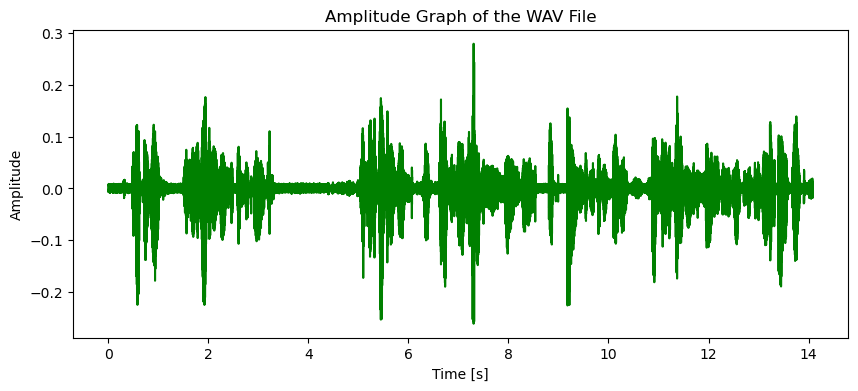

In [112]:
plot_waveform(raw_data, sample_rate)

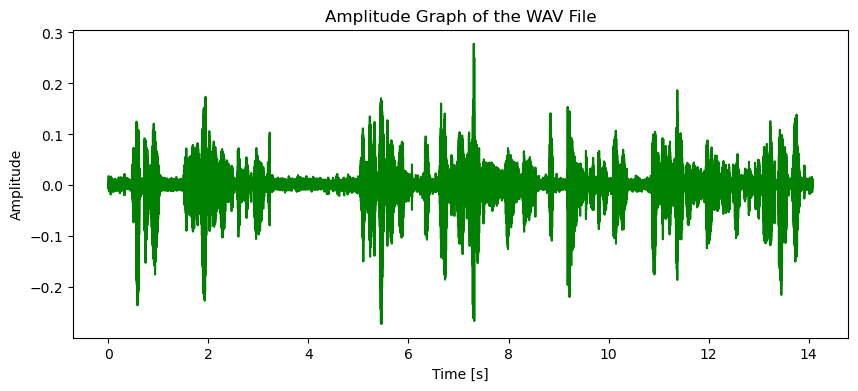

In [113]:
plot_waveform(denoised_audio, sample_rate)

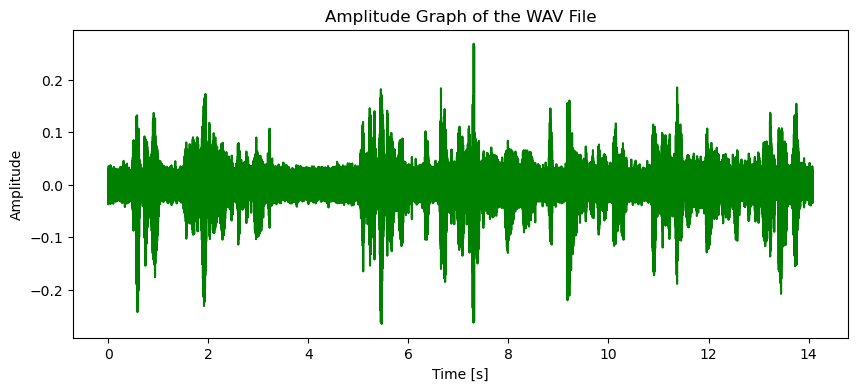

In [114]:
plot_waveform(raw_data_noisy, sample_rate)

In [115]:
# Save the denoised audio
sf.write('model_denoised.flac', denoised_audio, sample_rate)

In [122]:
play_audio('model_denoised.flac', "Model denoised result")

## Model denoised result

## 2D Unet

In [36]:
spectogram = calc_audio_stft(raw_data)

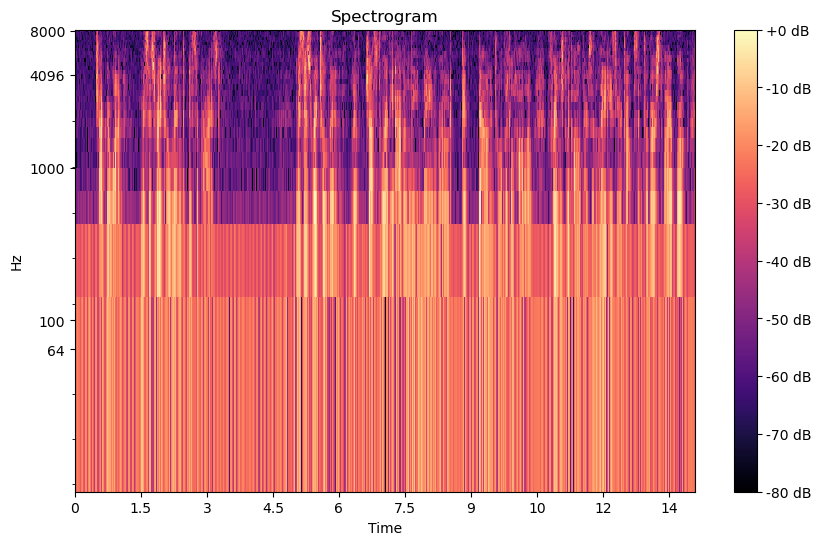

In [40]:
plot_spectogram(spectogram, sample_rate)

In [74]:
spectogram_noisy = calc_audio_stft(raw_data_noisy)

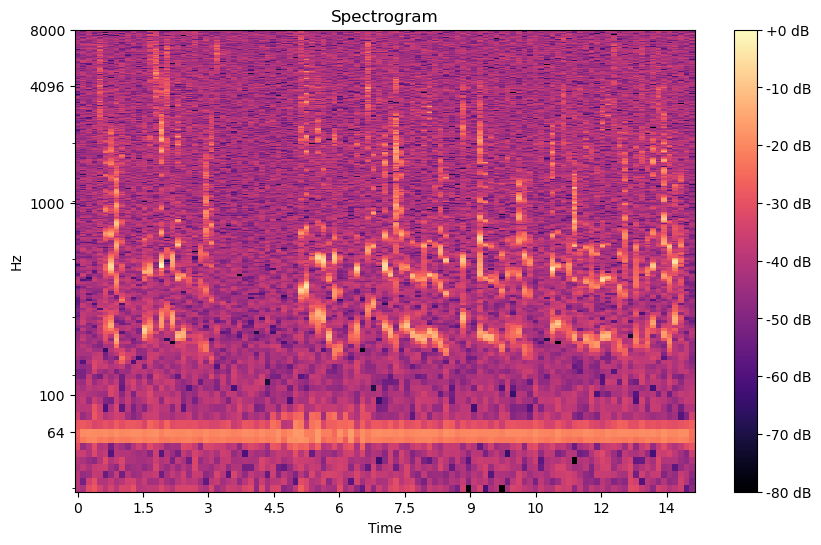

In [75]:
plot_spectogram(spectogram_noisy, sample_rate)

In [76]:
#minmax-normalization
clean_spectogram = (spectogram - spectogram.min()) / (spectogram.max() - spectogram.min())
noisy_spectogram = (spectogram_noisy - spectogram_noisy.min()) / (spectogram_noisy.max() - spectogram_noisy.min())

In [77]:
clean_spectogram = clean_spectogram.reshape((clean_spectogram.shape[0], clean_spectogram.shape[1], 1))  # Add channel dimension
noisy_spectogram = noisy_spectogram.reshape((noisy_spectogram.shape[0], noisy_spectogram.shape[1], 1))

In [78]:
assert(clean_spectogram.shape == noisy_spectogram.shape)

In [79]:
clean_spectogram.shape

(1025, 111, 1)

In [81]:
def unet_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    print(f"Layer 1 shape: {p1.shape}")

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    print(f"Layer 2 shape: {p2.shape}")

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    print(f"Layer 3 shape: {p3.shape}")

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)
    print(f"Layer 4 shape: {p4.shape}")

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)
    print(f"Layer 5 shape: {c5.shape}")

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    print(f"Layer 6 shape: {u6.shape}")
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    print(f"Layer 7 shape: {u7.shape}")
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    print(f"Layer 8 shape: {u8.shape}")
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    print(f"Layer 9 shape: {u9.shape}")
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])

    return model


In [82]:
model = unet_model(input_shape=clean_spectogram.shape)  # Adjust input shape based on your spectrogram size
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

Layer 1 shape: (None, 512, 55, 64)
Layer 2 shape: (None, 256, 27, 128)
Layer 3 shape: (None, 128, 13, 256)
Layer 4 shape: (None, 64, 6, 512)
Layer 5 shape: (None, 64, 6, 1024)
Layer 6 shape: (None, 128, 12, 512)


ValueError: A `Concatenate` layer requires inputs with matching shapes except for the concatenation axis. Received: input_shape=[(None, 128, 12, 512), (None, 128, 13, 512)]